### EDA on the dataset to see what preprocessing needs to be done

In [19]:
#imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Since the dataset was distributed across multiple files for the different food groups, we first have to consolidate them into one dataset before perfoming any kind of analysis

In [4]:
file_paths = [
    "../data/raw/FOOD-DATA-GROUP1.csv",
    "../data/raw/FOOD-DATA-GROUP2.csv",
    "../data/raw/FOOD-DATA-GROUP3.csv",
    "../data/raw/FOOD-DATA-GROUP4.csv",
    "../data/raw/FOOD-DATA-GROUP5.csv"
]

food_dfs = [pd.read_csv(file) for file in file_paths]

In [6]:
# combine
df = pd.concat(food_dfs, ignore_index=True)

#seeing what it looks like
df.head()

,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,0,0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,...,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,1,1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,...,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,2,2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,3,3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,...,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,4,4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,...,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007


In [7]:
print(df.shape)
print(df.columns)
print(df.info())

(2395, 37)
Index(['Unnamed: 0.1', 'Unnamed: 0', 'food', 'Caloric Value', 'Fat',
       'Saturated Fats', 'Monounsaturated Fats', 'Polyunsaturated Fats',
       'Carbohydrates', 'Sugars', 'Protein', 'Dietary Fiber', 'Cholesterol',
       'Sodium', 'Water', 'Vitamin A', 'Vitamin B1', 'Vitamin B11',
       'Vitamin B12', 'Vitamin B2', 'Vitamin B3', 'Vitamin B5', 'Vitamin B6',
       'Vitamin C', 'Vitamin D', 'Vitamin E', 'Vitamin K', 'Calcium', 'Copper',
       'Iron', 'Magnesium', 'Manganese', 'Phosphorus', 'Potassium', 'Selenium',
       'Zinc', 'Nutrition Density'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2395 entries, 0 to 2394
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0.1          2395 non-null   int64  
 1   Unnamed: 0            2395 non-null   int64  
 2   food                  2395 non-null   object 
 3   Caloric Value         2395 non-null   

Dropping junk columns. "Unnamed: 0.1" and "Unnamed: 0" just seem to be index leftovers so we can go ahead and just drop those

In [8]:
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])

In [20]:
# cleaning column names so we don't have to worry about spaces and cases
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [22]:
#checkign if they were dropped and column names changed
df.head()

,food,caloric_value,fat,saturated_fats,monounsaturated_fats,polyunsaturated_fats,carbohydrates,sugars,protein,dietary_fiber,...,calcium,copper,iron,magnesium,manganese,phosphorus,potassium,selenium,zinc,nutrition_density
0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,0.9,0.0,...,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,7.8,0.0,...,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,0.8,0.1,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,1.5,0.0,...,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,1.2,0.0,...,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007


In [24]:
df[["food", "caloric_value", "nutrition_density"]].head(20)

,food,caloric_value,nutrition_density
0,cream cheese,51,7.070
1,neufchatel cheese,215,130.100
2,requeijao cremoso light catupiry,49,5.400
3,ricotta cheese,30,5.196
4,cream cheese low fat,30,27.007
5,cream cheese fat free,19,67.679
6,gruyere cheese,116,300.694
7,cheddar cheese,113,215.530
8,parmesan cheese,71,224.777
9,romano cheese,19,56.380


### just to get an idea of distribution of the nutrition density data

In [27]:
df["nutrition_density"].describe()

count    2395.000000
mean      106.929006
std       173.023891
min         0.000000
25%        16.876500
50%        53.840000
75%       135.074500
max      3911.400000
Name: nutrition_density, dtype: float64

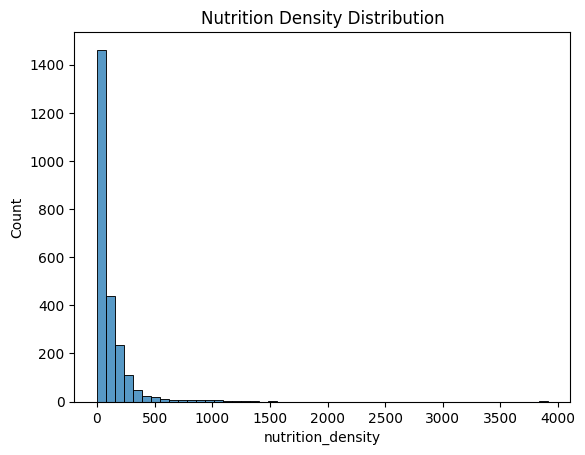

In [28]:
sns.histplot(df["nutrition_density"], bins=50)
plt.title("Nutrition Density Distribution")
plt.show()

- Nutrition density seems to be highly skewed

### Checking calories distribution

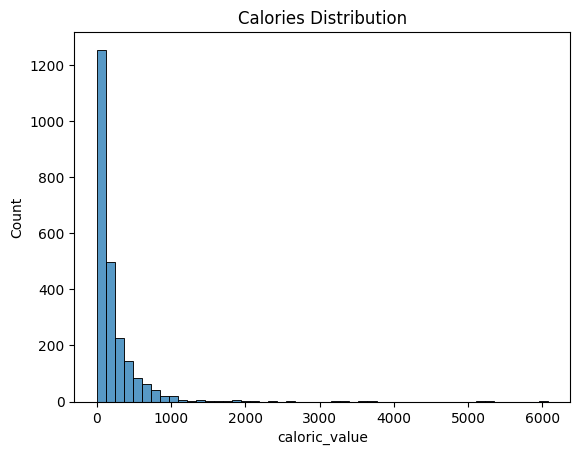

In [30]:
sns.histplot(df["caloric_value"], bins=50)
plt.title("Calories Distribution")
plt.show()

- Most foods are low/moderate calories
- Some extreme high calorie outliers still exist 

### Checking relationship between calories and nutrition

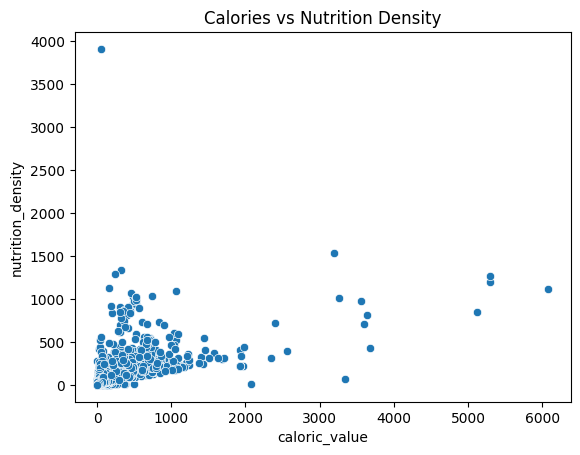

In [31]:
sns.scatterplot(x="caloric_value", y="nutrition_density", data=df)
plt.title("Calories vs Nutrition Density")
plt.show()

- The scatterplot shows that there's no strong correlation between caloric value and nutrition density
- Many high calorie foods don't provide proportionally high nutritional value whereas some lower calorie foods offer high nutrition density
- There are also several extreme outliers present, indicating that some foods may disproportionately influence optimization results.

### Why this matters for us

Selecting foods based on calories alone doesn't guarantee maximizing nutritional value. The lack of a clear relationship between calories and nutrition density shows that sleecting foods based on a single factor is insufficient. So an optimization algo like 0/1 knapsack is needed here to balance both constraints simultaneously.

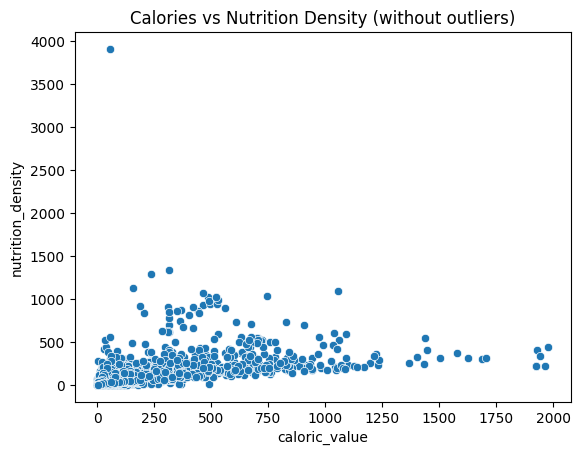

In [33]:
df_filtered = df[df["caloric_value"] < 2000]

sns.scatterplot(x="caloric_value", y="nutrition_density", data=df_filtered)
plt.title("Calories vs Nutrition Density (without outliers)")
plt.show()

- just visualized same scatterplot from above but without the outliers so it's easier to see the main cluster

### Checking for duplicates

In [34]:
df.duplicated().sum()

np.int64(0)

- no duplicates so no need to drop anything

Saw from above that there are foods for which nutrition and calories are 0 so just checking what those look like and if they should be dropped
### Zero check

In [35]:
print(df[(df["caloric_value"] == 0)])

                                 food  caloric_value    fat  saturated_fats  \
628                       baking soda              0  0.000           0.000   
743   milk chocolate with rice cereal              0  0.000           0.000   
1025                          epazote              0  0.060           0.000   
1047                             salt              0  0.000           0.000   
1200                veal shoulder raw              0  0.000           0.000   
1493             coffee decaffeinated              0  0.000           0.087   
1505     powerade zero ion4 coca cola              0  0.000           0.000   
1549                     water dannon              0  0.000           0.000   
1550                        tap water              0  0.000           0.000   
1551                      table water              0  0.000           0.000   
1553                            water              0  0.000           0.000   
1554             cola light coca cola              0

In [37]:
print(df[(df["nutrition_density"] == 0)])

                                 food  caloric_value  fat  saturated_fats  \
567                               gin             53  0.0             0.0   
628                       baking soda              0  0.0             0.0   
743   milk chocolate with rice cereal              0  0.0             0.0   
762               eisbonbons mac iver             23  0.0             0.0   
1200                veal shoulder raw              0  0.0             0.0   
1546          apple juice martinellis            122  0.0             0.0   
1554             cola light coca cola              0  0.0             0.0   
1573                 pesca tea santal            116  0.0            28.1   
1663        nesfit diet cereal nestle             75  0.0            14.5   

      monounsaturated_fats  polyunsaturated_fats  carbohydrates  sugars  \
567                    0.0                   0.0            0.0     0.0   
628                    0.0                   0.0            0.0     0.0   
743 

### Why this violates knapsack assumptions

- There are items with zero calories and zero nutrition

- However,the problem is in the items that are zero calorie but non zero nutrition. Items with zero caloric value but positive nutrition density violate the assumptions of the knapsack problem since they provide value without contributing to the weight constraint. 

- As a result, the algorithm would always select such items leading to unrealistic optimzation results.

- The algorithm is basically getting free nutrition to put it simply when it's actually supposed to model choosing foods under a calorie budget.

- Items with zero caloric value and zero nutrition don't contribute anything to either the objective function or the constraint so including them has no effect on the optimization. We're juts removing those too to avoid unnecessary noise in the dataset and ensure cleaner and more meaningful output

In [38]:
df = df[df["caloric_value"] > 0]

In [39]:
# saving clean df as a csv under the processed dir
df.to_csv("../data/processed/clean_food_data.csv", index=False)

### Preprocessing summary

1) After combining the 5 Kaggle food data files into one dataframe, the final dataset contained 2,395 food items and 37 columns. 

2) The dataset did not have any missing values so no imputation was needed

3) For this project, only the columns neede for the knapsack setuo were kept:
 - `food` -> item name
 - `caloric_value` -> item weight
 - `nutrition_density` -> item value/ nutrition score

4) Columns names were standardized to lowercase with underscores to make it easier to use in code

5) The 2 extra index columns `unammed:_0` and `unnamed:_0.1` were removed because they were not actual food features

6) Rows with zero calories were removed. This was done because zero calorie items don't contribute to the calorie constraint

7) The final cleaned dataset keeps the og `nutrition_density` value as the nutrition score

NOTE: Since this is an algorithms project, the score is treated as a black box metric provided by the dataset rather than recalculated manually since that would mean going into the nittygritty of how nutrition score should be calculated which is not relevant to the goal of this project

### Expected Knapsack Behavior

The knapsack algorithm should use the cleaned dataset created during preprocessing (available as `clean_food_data.csv` under `data/processed/`)

For each food item:

- item name = `food`
- weight = `caloric_value`
- value = `nutrition_density`

The user should provide:

1. a calorie limit
2. a list of selected food items

The algorithm should only run on the foods selected by the user and not the entire dataset

The goal is to choose the subset of selected foods that maximizes total nutrition score while also staying within the user’s calorie limit that they enter

so basically:

maximize total `nutrition_density`

subject to:

total `caloric_value` <= user calorie limit

The output should include:

- list of chosen foods
- each chosen food’s name
- each chosen food’s calories
- each chosen food’s nutrition score
- total calories used
- total nutrition score
- remaining calories

If a selected food is not found in the cleaned dataset, it should either be skipped with a warning or shown as unavailable. The algorithm should not include foods that exceed the calorie limit unless they are part of a valid combination that stays within the total limit.